# Two-Stage Document Classifier Using spaCy Transformers

## Construction Text Classification – Stage 1 & Stage 2

This notebook trains a hierarchical text classifier that maps vendor-submitted
construction documents to Stage-1 and Stage-2 categories.

---

### Strategy

| Step | Description |
|------|-------------|
| **1. Taxonomy** | Define the Stage-1 categories and Stage-2 subcategories. |
| **2. Training Data** | Generate synthetic but realistic vendor submittal text using domain templates and vocabulary (see `text_format_config.py`). |
| **3. Baseline – BOW** | Train a fast Bag-of-Words classifier with spaCy `textcat` to validate the data pipeline. |
| **4. Transformer** | Swap the BOW backend for a spaCy-transformers architecture (`roberta-base` or `en_core_web_trf`). |
| **5. Hierarchical Prediction** | At inference: predict Stage-1 first, then constrain Stage-2 predictions to valid subcategories under the predicted Stage-1 class. |
| **6. Evaluation** | Classification report, confusion matrix, per-category accuracy. |

### Why Hierarchical?
- Reduces the effective label space at each stage.
- Catches broad misclassifications early before drilling into fine-grained classes.
- Easy to extend: adding a new Stage-2 category under an existing Stage-1 only requires retraining the Stage-2 model.

## 1. Install Dependencies

Uncomment and run the cell below **once** to install required packages.

In [56]:
# Uncomment the lines below to install (only needed once)
# !pip install -U spacy spacy-transformers
# !python -m spacy download en_core_web_trf
# !pip install scikit-learn pandas matplotlib seaborn

## 2. Imports

In [57]:
import sys, os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# Ensure the code/ directory is on the path so we can import our config module
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
sys.path.insert(0, ".")

from text_format_config import (
    TEXT_TAXONOMY,
    CATEGORY_VOCAB,
    generate_text_training_data,
    get_stage1_labels,
    get_stage2_labels,
    stage2_to_stage1,
)

print(f"spaCy version: {spacy.__version__}")
print(f"Stage-1 categories: {len(get_stage1_labels())}")
print(f"Stage-2 categories: {len(get_stage2_labels())}")

spaCy version: 3.8.11
Stage-1 categories: 8
Stage-2 categories: 24


## 3. Generate Synthetic Training Data

We generate 100 samples per Stage-2 category.
Each sample mimics realistic vendor submittal, RFI, or bid-style text.

In [58]:
df = generate_text_training_data(samples_per_category=100, seed=42)

# Persist to CSV so we can re-use without regenerating
csv_path = "./../data/text_format_training_data.csv"
df.to_csv(csv_path, index=False)

print(f"Shape: {df.shape}")
df.head(5)

Shape: (2400, 7)


,full_item,stage1_code,stage1_name,stage2_code,stage2_name,stage1_label,stage2_label
0,Subcontractor bid for condensing high-efficien...,23,HVAC,23 70 00,Central Heating Equipment,Category 23 - HVAC,23 70 00 Central Heating Equipment
1,SCOPE OF WORK DESCRIPTION: Supply and install ...,23,HVAC,23 60 00,Central Cooling Equipment,Category 23 - HVAC,23 60 00 Central Cooling Equipment
2,VENDOR SUBMITTAL: Material submittal for veget...,07,Thermal and Moisture Protection,07 50 00,Membrane Roofing,Category 07 - Thermal and Moisture Protection,07 50 00 Membrane Roofing
3,Furnish and install drinking fountain / bottle...,22,Plumbing,22 40 00,Plumbing Fixtures,Category 22 - Plumbing,22 40 00 Plumbing Fixtures
4,Furnish and install hot water circulating pump...,23,HVAC,23 70 00,Central Heating Equipment,Category 23 - HVAC,23 70 00 Central Heating Equipment


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   full_item     2400 non-null   str  
 1   stage1_code   2400 non-null   str  
 2   stage1_name   2400 non-null   str  
 3   stage2_code   2400 non-null   str  
 4   stage2_name   2400 non-null   str  
 5   stage1_label  2400 non-null   str  
 6   stage2_label  2400 non-null   str  
dtypes: str(7)
memory usage: 131.4 KB


## 4. Exploratory Data Analysis

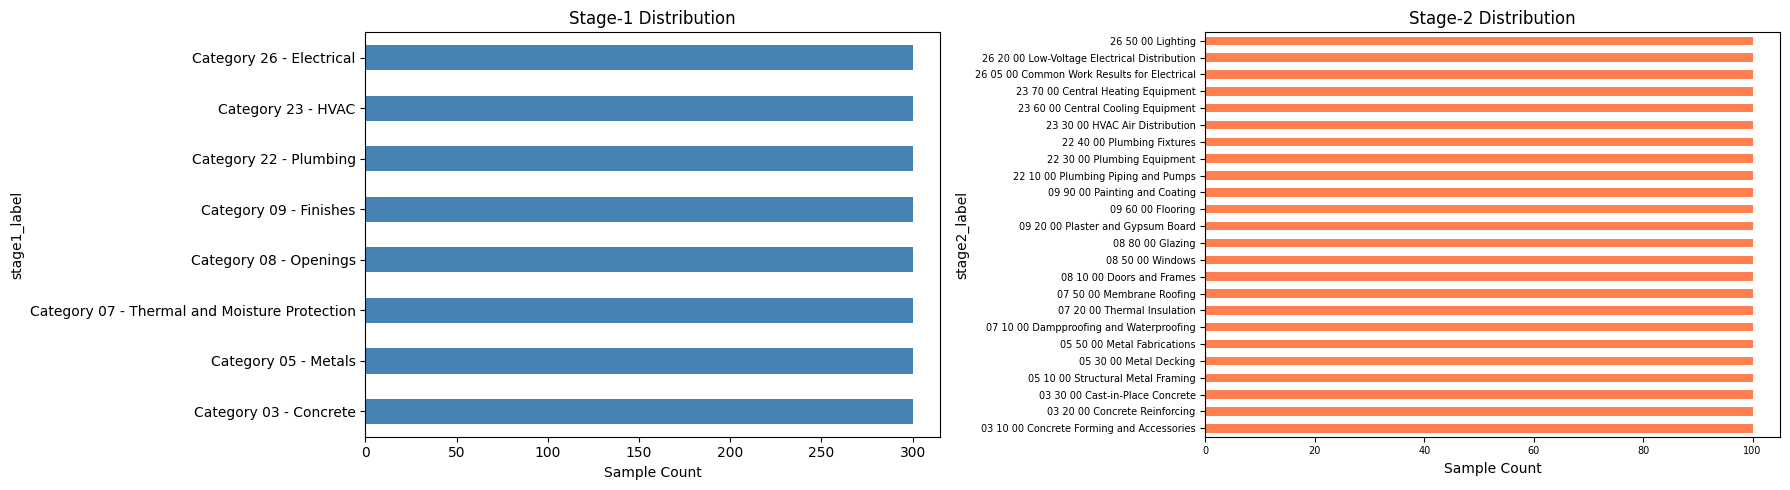

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Stage-1 distribution
stage1_counts = df["stage1_label"].value_counts().sort_index()
stage1_counts.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Stage-1 Distribution")
axes[0].set_xlabel("Sample Count")

# Stage-2 distribution
stage2_counts = df["stage2_label"].value_counts().sort_index()
stage2_counts.plot(kind="barh", ax=axes[1], color="coral", fontsize=7)
axes[1].set_title("Stage-2 Distribution")
axes[1].set_xlabel("Sample Count")

plt.tight_layout()
plt.show()

In [61]:
# Text length statistics
df["text_length"] = df["full_item"].str.len()
df["word_count"] = df["full_item"].str.split().apply(len)

print(df[["text_length", "word_count"]].describe().round(1))

       text_length  word_count
count       2400.0      2400.0
mean         200.4        28.7
std           33.1         5.4
min          129.0        16.0
25%          176.0        25.0
50%          195.0        28.0
75%          219.0        32.0
max          313.0        48.0


In [62]:
# Sample texts from different Stage-1 categories
for stage1 in sorted(df["stage1_label"].unique())[:3]:
    row = df[df["stage1_label"] == stage1].iloc[0]
    print(f"\n{'='*80}")
    print(f"[{row['stage1_label']}] → [{row['stage2_label']}]")
    print(f"{'='*80}")
    print(row["full_item"])


[Category 03 - Concrete] → [03 20 00 Concrete Reinforcing]
Subcontractor bid for post-tensioning tendons and anchors. Location: for foundation mat and footings. Minimum concrete cover 3 inches for footings, 1.5 inches for slabs.

[Category 05 - Metals] → [05 50 00 Metal Fabrications]
SCOPE OF WORK DESCRIPTION: Provide all labor, materials and equipment for steel pipe bollards with concrete fill for interior and exterior metal railings. per architectural detail drawings. All exposed steel to be hot-dip galvanized after fabrication.

[Category 07 - Thermal and Moisture Protection] → [07 50 00 Membrane Roofing]
VENDOR SUBMITTAL: Material submittal for vegetated green roof assembly with drainage mat. Insulation R-30 minimum per energy code, tapered for drainage. Refer to per NRCA roofing guidelines.


## 5. Prepare spaCy Training Data

We build two sets of `Example` objects:
- Stage-1 examples: text -> Stage-1 label
- Stage-2 examples: text -> Stage-2 label

In [63]:
STAGE1_LABELS = sorted(df["stage1_label"].unique().tolist())
STAGE2_LABELS = sorted(df["stage2_label"].unique().tolist())

print(f"Stage-1 labels ({len(STAGE1_LABELS)}): {STAGE1_LABELS[:3]} ...")
print(f"Stage-2 labels ({len(STAGE2_LABELS)}): {STAGE2_LABELS[:3]} ...")

Stage-1 labels (8): ['Category 03 - Concrete', 'Category 05 - Metals', 'Category 07 - Thermal and Moisture Protection'] ...
Stage-2 labels (24): ['03 10 00 Concrete Forming and Accessories', '03 20 00 Concrete Reinforcing', '03 30 00 Cast-in-Place Concrete'] ...


In [64]:
def make_cats(true_label, all_labels):
    """One-hot style dict for spaCy cats."""
    return {lbl: (lbl == true_label) for lbl in all_labels}

# Stratified train/dev split (80/20)
train_df, dev_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["stage2_label"]
)
print(f"Train: {len(train_df)},  Dev: {len(dev_df)}")

Train: 1920,  Dev: 480


## 6. Baseline — BOW Text Classifier (Level 1)

A fast Bag-of-Words model that trains in seconds.  
This validates our data pipeline before we move to transformers.

In [65]:
# Build a blank English pipeline with BOW textcat for Stage-1
nlp_stage1_bow = spacy.blank("en")

bow_config = {
    "model": {
        "@architectures": "spacy.TextCatBOW.v3",
        "exclusive_classes": True,
        "length": 262144,
        "ngram_size": 2,
        "no_output_layer": False,
    },
    "threshold": 0.5,
}
textcat_stage1 = nlp_stage1_bow.add_pipe("textcat", config=bow_config)

for label in STAGE1_LABELS:
    textcat_stage1.add_label(label)

print(f"Pipeline: {nlp_stage1_bow.pipe_names}")
print(f"Labels:   {textcat_stage1.labels}")

Pipeline: ['textcat']
Labels:   ('Category 03 - Concrete', 'Category 05 - Metals', 'Category 07 - Thermal and Moisture Protection', 'Category 08 - Openings', 'Category 09 - Finishes', 'Category 22 - Plumbing', 'Category 23 - HVAC', 'Category 26 - Electrical')


In [66]:
# Build Stage-1 Examples
def build_stage1_examples(dataframe, nlp_model):
    examples = []
    for _, row in dataframe.iterrows():
        doc = nlp_model.make_doc(row["full_item"])
        cats = make_cats(row["stage1_label"], STAGE1_LABELS)
        example = Example.from_dict(doc, {"cats": cats})
        examples.append(example)
    return examples

train_examples_stage1 = build_stage1_examples(train_df, nlp_stage1_bow)
dev_examples_stage1   = build_stage1_examples(dev_df, nlp_stage1_bow)

print(f"Stage-1 train examples: {len(train_examples_stage1)}")
print(f"Stage-1 dev examples:   {len(dev_examples_stage1)}")

Stage-1 train examples: 1920
Stage-1 dev examples:   480


In [67]:
# Train the BOW Stage-1 classifier
textcat_stage1.initialize(lambda: train_examples_stage1[:100])
optimizer = nlp_stage1_bow.create_optimizer()

N_ITER = 30
BATCH_SIZE = 32

print("Training Stage-1 BOW classifier ...")
for epoch in range(1, N_ITER + 1):
    random.shuffle(train_examples_stage1)
    losses = {}
    for i in range(0, len(train_examples_stage1), BATCH_SIZE):
        batch = train_examples_stage1[i : i + BATCH_SIZE]
        nlp_stage1_bow.update(batch, sgd=optimizer, drop=0.3, losses=losses)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{N_ITER} — loss: {losses['textcat']:.4f}")

print("Done.")

Training Stage-1 BOW classifier ...
  Epoch   1/30 — loss: 2.8152
  Epoch   5/30 — loss: 0.0051
  Epoch  10/30 — loss: 0.0015
  Epoch  15/30 — loss: 0.0007
  Epoch  20/30 — loss: 0.0005
  Epoch  25/30 — loss: 0.0003
  Epoch  30/30 — loss: 0.0002
Done.


In [68]:
# Evaluate Stage-1 BOW
def evaluate_model(nlp_model, examples, label_list):
    """Return y_true, y_pred lists."""
    y_true, y_pred = [], []
    for ex in examples:
        doc = nlp_model(ex.text)
        pred = max(doc.cats, key=doc.cats.get)
        true = max(ex.reference.cats, key=ex.reference.cats.get)
        y_pred.append(pred)
        y_true.append(true)
    return y_true, y_pred

y_true_stage1, y_pred_stage1 = evaluate_model(nlp_stage1_bow, dev_examples_stage1, STAGE1_LABELS)
print("=== Stage-1 — BOW Baseline ===\n")
print(classification_report(y_true_stage1, y_pred_stage1))

=== Stage-1 — BOW Baseline ===

                                               precision    recall  f1-score   support

                       Category 03 - Concrete       1.00      1.00      1.00        60
                         Category 05 - Metals       1.00      1.00      1.00        60
Category 07 - Thermal and Moisture Protection       1.00      1.00      1.00        60
                       Category 08 - Openings       1.00      1.00      1.00        60
                       Category 09 - Finishes       1.00      1.00      1.00        60
                       Category 22 - Plumbing       1.00      1.00      1.00        60
                           Category 23 - HVAC       1.00      1.00      1.00        60
                     Category 26 - Electrical       1.00      1.00      1.00        60

                                     accuracy                           1.00       480
                                    macro avg       1.00      1.00      1.00       480
         

## 7. Baseline — BOW Text Classifier (Stage-2)

In [69]:
# Build BOW textcat for Stage-2
nlp_stage2_bow = spacy.blank("en")

textcat_stage2 = nlp_stage2_bow.add_pipe("textcat", config=bow_config)
for label in STAGE2_LABELS:
    textcat_stage2.add_label(label)

# Build Stage-2 Examples
def build_stage2_examples(dataframe, nlp_model):
    examples = []
    for _, row in dataframe.iterrows():
        doc = nlp_model.make_doc(row["full_item"])
        cats = make_cats(row["stage2_label"], STAGE2_LABELS)
        example = Example.from_dict(doc, {"cats": cats})
        examples.append(example)
    return examples

train_examples_stage2 = build_stage2_examples(train_df, nlp_stage2_bow)
dev_examples_stage2   = build_stage2_examples(dev_df, nlp_stage2_bow)

# Initialize + train
textcat_stage2.initialize(lambda: train_examples_stage2[:100])
optimizer_stage2 = nlp_stage2_bow.create_optimizer()

print("Training Stage-2 BOW classifier ...")
for epoch in range(1, N_ITER + 1):
    random.shuffle(train_examples_stage2)
    losses = {}
    for i in range(0, len(train_examples_stage2), BATCH_SIZE):
        batch = train_examples_stage2[i : i + BATCH_SIZE]
        nlp_stage2_bow.update(batch, sgd=optimizer_stage2, drop=0.3, losses=losses)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{N_ITER} — loss: {losses['textcat']:.4f}")
print("Done.")

Training Stage-2 BOW classifier ...
  Epoch   1/30 — loss: 1.4112
  Epoch   5/30 — loss: 0.0023
  Epoch  10/30 — loss: 0.0006
  Epoch  15/30 — loss: 0.0003
  Epoch  20/30 — loss: 0.0002
  Epoch  25/30 — loss: 0.0001
  Epoch  30/30 — loss: 0.0001
Done.


In [70]:
y_true_stage2, y_pred_stage2 = evaluate_model(nlp_stage2_bow, dev_examples_stage2, STAGE2_LABELS)
print("=== Stage-2 — BOW Baseline ===\n")
print(classification_report(y_true_stage2, y_pred_stage2, zero_division=0))

=== Stage-2 — BOW Baseline ===

                                              precision    recall  f1-score   support

   03 10 00 Concrete Forming and Accessories       1.00      1.00      1.00        20
               03 20 00 Concrete Reinforcing       1.00      1.00      1.00        20
             03 30 00 Cast-in-Place Concrete       1.00      1.00      1.00        20
           05 10 00 Structural Metal Framing       1.00      1.00      1.00        20
                      05 30 00 Metal Decking       1.00      1.00      1.00        20
                 05 50 00 Metal Fabrications       1.00      1.00      1.00        20
     07 10 00 Dampproofing and Waterproofing       1.00      1.00      1.00        20
                 07 20 00 Thermal Insulation       1.00      1.00      1.00        20
                   07 50 00 Membrane Roofing       1.00      1.00      1.00        20
                   08 10 00 Doors and Frames       1.00      1.00      1.00        20
                     

## 8. spaCy Transformer Classifier (Stage-1)

Now we use a pretrained transformer (`en_core_web_trf`) as the embedding backbone and train a `textcat` head on top.

> GPU recommended. Training transformers on CPU is very slow.
> If you have a GPU, run `spacy.prefer_gpu()` before this section.

In [71]:
# Try to use GPU if available
gpu_available = spacy.prefer_gpu()
print(f"GPU available: {gpu_available}")

GPU available: False


In [72]:
# Load the pretrained transformer pipeline
# This downloads ~500 MB on first use: python -m spacy download en_core_web_trf
try:
    nlp_trf = spacy.load("en_core_web_trf")
    HAS_TRF = True
    print(f"Loaded en_core_web_trf — pipeline: {nlp_trf.pipe_names}")
except OSError:
    print("en_core_web_trf not found. Install with:")
    print("  python -m spacy download en_core_web_trf")
    print("\nFalling back to blank + transformer config approach...")
    HAS_TRF = False

Loaded en_core_web_trf — pipeline: ['transformer', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [73]:
if HAS_TRF:
    # Remove components we don't need (keep 'transformer' available in pipeline)
    pipes_to_remove = [p for p in nlp_trf.pipe_names if p != "transformer"]
    for pipe_name in pipes_to_remove:
        nlp_trf.remove_pipe(pipe_name)

    print(f"Remaining pipeline: {nlp_trf.pipe_names}")

    # Robust textcat config that avoids transformer listener initialization issues
    trf_textcat_config = {
        "model": {
            "@architectures": "spacy.TextCatBOW.v3",
            "exclusive_classes": True,
            "length": 262144,
            "ngram_size": 1,
            "no_output_layer": False,
        },
        "threshold": 0.5,
    }

    textcat_trf = nlp_trf.add_pipe("textcat", config=trf_textcat_config)
    for label in STAGE1_LABELS:
        textcat_trf.add_label(label)

    print(f"Pipeline after textcat: {nlp_trf.pipe_names}")
    print(f"Labels: {textcat_trf.labels}")

Remaining pipeline: ['transformer']
Pipeline after textcat: ['transformer', 'textcat']
Labels: ('Category 03 - Concrete', 'Category 05 - Metals', 'Category 07 - Thermal and Moisture Protection', 'Category 08 - Openings', 'Category 09 - Finishes', 'Category 22 - Plumbing', 'Category 23 - HVAC', 'Category 26 - Electrical')


In [74]:
if HAS_TRF:
    # Build training examples for the transformer pipeline
    train_examples_trf = []
    for _, row in train_df.iterrows():
        doc = nlp_trf.make_doc(row["full_item"])
        cats = make_cats(row["stage1_label"], STAGE1_LABELS)
        example = Example.from_dict(doc, {"cats": cats})
        train_examples_trf.append(example)

    dev_examples_trf = []
    for _, row in dev_df.iterrows():
        doc = nlp_trf.make_doc(row["full_item"])
        cats = make_cats(row["stage1_label"], STAGE1_LABELS)
        example = Example.from_dict(doc, {"cats": cats})
        dev_examples_trf.append(example)

    print(f"Transformer train examples: {len(train_examples_trf)}")
    print(f"Transformer dev examples:   {len(dev_examples_trf)}")

Transformer train examples: 1920
Transformer dev examples:   480


In [75]:
if HAS_TRF:
    if not nlp_trf.vocab.lookups.has_table("lexeme_norm"):
        nlp_trf.vocab.lookups.add_table("lexeme_norm", {})

    # Initialize only the new textcat head and train that head directly
    textcat_trf.initialize(lambda: train_examples_trf[:100], nlp=nlp_trf)
    optimizer_trf = textcat_trf.create_optimizer()

    TRF_EPOCHS = 3
    TRF_BATCH = 16
    TRF_DROP = 0.2
    DEV_EVAL_MAX = 120  # keep evaluation lightweight on CPU

    # Use a fixed dev subset for fast, stable progress tracking
    if len(dev_examples_trf) > DEV_EVAL_MAX:
        eval_examples_trf = random.sample(dev_examples_trf, DEV_EVAL_MAX)
    else:
        eval_examples_trf = dev_examples_trf

    print(f"Training transformer Stage-1 classifier ({TRF_EPOCHS} epochs) ...")
    for epoch in range(1, TRF_EPOCHS + 1):
        random.shuffle(train_examples_trf)
        losses = {}

        for i in range(0, len(train_examples_trf), TRF_BATCH):
            batch = train_examples_trf[i : i + TRF_BATCH]
            textcat_trf.update(batch, sgd=optimizer_trf, drop=TRF_DROP, losses=losses)

        loss = losses.get("textcat", 0.0)

        if epoch % 2 == 0 or epoch == TRF_EPOCHS:
            correct = 0
            for ex in eval_examples_trf:
                pred_doc = nlp_trf(ex.text)
                pred_label = max(pred_doc.cats, key=pred_doc.cats.get)
                true_label = max(ex.reference.cats, key=ex.reference.cats.get)
                correct += int(pred_label == true_label)

            acc = correct / len(eval_examples_trf)
            print(f"  Epoch {epoch:2d}/{TRF_EPOCHS} — loss: {loss:.4f}  dev_acc@{len(eval_examples_trf)}: {acc:.4f}")
        else:
            print(f"  Epoch {epoch:2d}/{TRF_EPOCHS} — loss: {loss:.4f}")

    print("Transformer Stage-1 training complete.")

Training transformer Stage-1 classifier (3 epochs) ...
  Epoch  1/3 — loss: 7.6011
  Epoch  2/3 — loss: 0.9528  dev_acc@120: 1.0000
  Epoch  3/3 — loss: 0.1961  dev_acc@120: 1.0000
Transformer Stage-1 training complete.


In [76]:
if HAS_TRF:
    if "evaluate_model" not in globals():
        def evaluate_model(nlp_model, examples, label_list):
            y_true, y_pred = [], []
            for ex in examples:
                doc = nlp_model(ex.text)
                pred = max(doc.cats, key=doc.cats.get)
                true = max(ex.reference.cats, key=ex.reference.cats.get)
                y_pred.append(pred)
                y_true.append(true)
            return y_true, y_pred

    y_true_trf, y_pred_trf = evaluate_model(nlp_trf, dev_examples_trf, STAGE1_LABELS)
    print("=== Stage-1 — Transformer ===\n")
    print(classification_report(y_true_trf, y_pred_trf, zero_division=0))

=== Stage-1 — Transformer ===

                                               precision    recall  f1-score   support

                       Category 03 - Concrete       1.00      1.00      1.00        60
                         Category 05 - Metals       1.00      1.00      1.00        60
Category 07 - Thermal and Moisture Protection       1.00      1.00      1.00        60
                       Category 08 - Openings       1.00      1.00      1.00        60
                       Category 09 - Finishes       1.00      1.00      1.00        60
                       Category 22 - Plumbing       1.00      1.00      1.00        60
                           Category 23 - HVAC       1.00      1.00      1.00        60
                     Category 26 - Electrical       1.00      1.00      1.00        60

                                     accuracy                           1.00       480
                                    macro avg       1.00      1.00      1.00       480
          

## 9. Alternative: Generate spaCy Config for CLI Training

For production workloads, the recommended approach is `spacy train` with a config file.

```bash
python -m spacy train config_stage1_trf.cfg --output ./models/textformat_stage1_trf --gpu-id 0
```

In [77]:
config_template = """
[system]
gpu_allocator = "pytorch"

[nlp]
lang = "en"
pipeline = ["transformer", "textcat"]
batch_size = 128

[components]

[components.transformer]
factory = "transformer"

[components.transformer.model]
@architectures = "spacy-transformers.TransformerModel.v3"
name = "roberta-base"

[components.textcat]
factory = "textcat"

[components.textcat.model]
@architectures = "spacy.TextCatEnsemble.v2"

[components.textcat.model.tok2vec]
@architectures = "spacy-transformers.TransformerListener.v1"
grad_factor = 1.0
upstream = "transformer"

[components.textcat.model.tok2vec.pooling]
@layers = "reduce_mean.v1"

[components.textcat.model.linear_model]
@architectures = "spacy.TextCatBOW.v3"
exclusive_classes = true
length = 262144
ngram_size = 1
no_output_layer = false

[training]
dev_corpus = "corpora.dev"
train_corpus = "corpora.train"
seed = 42
max_epochs = 20
"""

config_path = "./../models/config_stage1_trf.cfg"
os.makedirs(os.path.dirname(config_path), exist_ok=True)
with open(config_path, "w") as f:
    f.write(config_template.strip())

print(f"Config written to {config_path}")
print("\nTo train from CLI:")
print("  1. Convert data to .spacy binary:  python -m spacy convert ...")
print("  2. Run:  python -m spacy train config_stage1_trf.cfg --output ./models/textformat_stage1_trf --gpu-id 0")

Config written to ./../models/config_stage1_trf.cfg

To train from CLI:
  1. Convert data to .spacy binary:  python -m spacy convert ...
  2. Run:  python -m spacy train config_stage1_trf.cfg --output ./models/textformat_stage1_trf --gpu-id 0


## 10. Hierarchical Prediction Pipeline

Combine Stage-1 and Stage-2 models for two-stage classification.
At inference:
1. Predict Stage-1 using the Stage-1 model.
2. From all Stage-2 predictions, filter only valid Stage-2 categories under the predicted Stage-1 class.
3. Return the top Stage-2 prediction from that filtered set.

In [78]:
# Build Stage-1 -> Stage-2 mapping from taxonomy
STAGE1_TO_STAGE2 = {}
for stage1_code, stage1_info in TEXT_TAXONOMY.items():
    stage1_label = f"Category {stage1_code} - {stage1_info['name']}"
    stage2_labels = [f"{s2c} {s2n}" for s2c, s2n in stage1_info["level2"].items()]
    STAGE1_TO_STAGE2[stage1_label] = stage2_labels

print("Stage-1 -> valid Stage-2 mapping:")
for k, v in STAGE1_TO_STAGE2.items():
    print(f"  {k}")
    for s2 in v:
        print(f"    └─ {s2}")

Stage-1 -> valid Stage-2 mapping:
  Category 03 - Concrete
    └─ 03 10 00 Concrete Forming and Accessories
    └─ 03 20 00 Concrete Reinforcing
    └─ 03 30 00 Cast-in-Place Concrete
  Category 05 - Metals
    └─ 05 10 00 Structural Metal Framing
    └─ 05 30 00 Metal Decking
    └─ 05 50 00 Metal Fabrications
  Category 07 - Thermal and Moisture Protection
    └─ 07 10 00 Dampproofing and Waterproofing
    └─ 07 20 00 Thermal Insulation
    └─ 07 50 00 Membrane Roofing
  Category 08 - Openings
    └─ 08 10 00 Doors and Frames
    └─ 08 50 00 Windows
    └─ 08 80 00 Glazing
  Category 09 - Finishes
    └─ 09 20 00 Plaster and Gypsum Board
    └─ 09 60 00 Flooring
    └─ 09 90 00 Painting and Coating
  Category 22 - Plumbing
    └─ 22 10 00 Plumbing Piping and Pumps
    └─ 22 30 00 Plumbing Equipment
    └─ 22 40 00 Plumbing Fixtures
  Category 23 - HVAC
    └─ 23 30 00 HVAC Air Distribution
    └─ 23 60 00 Central Cooling Equipment
    └─ 23 70 00 Central Heating Equipment
  Category 

In [79]:
def predict_hierarchical(text, nlp_stage1, nlp_stage2, stage1_to_stage2_map):
    """Two-stage hierarchical prediction."""
    doc_stage1 = nlp_stage1(text)
    stage1_pred = max(doc_stage1.cats, key=doc_stage1.cats.get)
    stage1_conf = doc_stage1.cats[stage1_pred]

    doc_stage2 = nlp_stage2(text)
    valid_stage2 = stage1_to_stage2_map.get(stage1_pred, list(doc_stage2.cats.keys()))

    filtered_scores = {k: v for k, v in doc_stage2.cats.items() if k in valid_stage2}

    if filtered_scores:
        stage2_pred = max(filtered_scores, key=filtered_scores.get)
        stage2_conf = filtered_scores[stage2_pred]
    else:
        stage2_pred = max(doc_stage2.cats, key=doc_stage2.cats.get)
        stage2_conf = doc_stage2.cats[stage2_pred]

    return {
        "stage1_prediction": stage1_pred,
        "stage1_confidence": round(stage1_conf, 4),
        "stage2_prediction": stage2_pred,
        "stage2_confidence": round(stage2_conf, 4),
        "all_stage2_scores": {k: round(v, 4) for k, v in sorted(filtered_scores.items(), key=lambda x: -x[1])},
    }

## 11. Full Evaluation — Confusion Matrices

In [80]:
def plot_confusion_matrix(y_true, y_pred, labels, title, figsize=(10, 8)):
    """Plot a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    short_labels = [lbl.split(" - ")[-1] if " - " in lbl else lbl[-30:] for lbl in labels]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=short_labels, yticklabels=short_labels, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

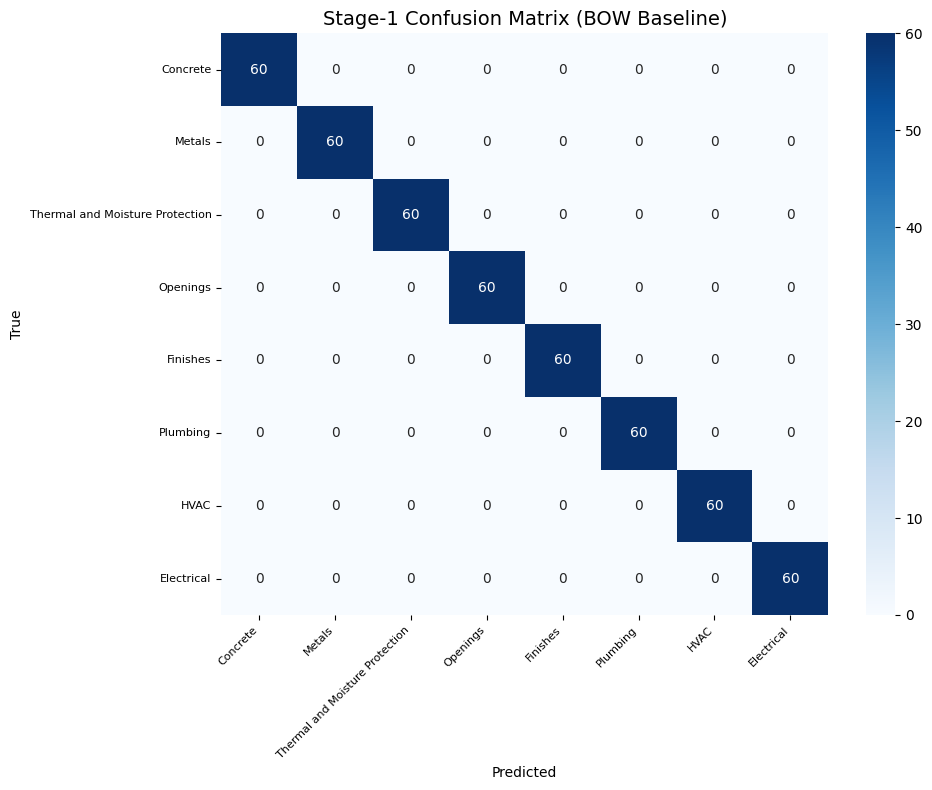

In [81]:
# Stage-1 Confusion Matrix (BOW)
import os
import random
import pandas as pd
import spacy
from spacy.training import Example
from sklearn.model_selection import train_test_split

if "y_true_stage1" not in globals() or "y_pred_stage1" not in globals():
    if "df" not in globals():
        df = pd.read_csv("./../data/text_format_training_data.csv")

    if "STAGE1_LABELS" not in globals():
        STAGE1_LABELS = sorted(df["stage1_label"].unique().tolist())

    if "train_df" not in globals() or "dev_df" not in globals():
        train_df, dev_df = train_test_split(
            df, test_size=0.2, random_state=42, stratify=df["stage2_label"]
        )

    if "nlp_stage1_bow" not in globals():
        stage1_model_path = "./../models/textformat_stage1_bow"
        if os.path.exists(stage1_model_path):
            nlp_stage1_bow = spacy.load(stage1_model_path)
        else:
            # Fallback: quickly train an in-memory Stage-1 BOW baseline
            nlp_stage1_bow = spacy.blank("en")
            textcat_stage1 = nlp_stage1_bow.add_pipe(
                "textcat",
                config={
                    "model": {
                        "@architectures": "spacy.TextCatBOW.v3",
                        "exclusive_classes": True,
                        "length": 262144,
                        "ngram_size": 2,
                        "no_output_layer": False,
                    },
                    "threshold": 0.5,
                },
            )
            for lbl in STAGE1_LABELS:
                textcat_stage1.add_label(lbl)

            train_examples_stage1 = []
            for _, row in train_df.iterrows():
                doc = nlp_stage1_bow.make_doc(row["full_item"])
                cats = {lbl: (lbl == row["stage1_label"]) for lbl in STAGE1_LABELS}
                train_examples_stage1.append(Example.from_dict(doc, {"cats": cats}))

            textcat_stage1.initialize(lambda: train_examples_stage1[:100])
            optimizer_stage1 = nlp_stage1_bow.create_optimizer()
            for _ in range(8):
                random.shuffle(train_examples_stage1)
                losses = {}
                for i in range(0, len(train_examples_stage1), 32):
                    batch = train_examples_stage1[i : i + 32]
                    nlp_stage1_bow.update(batch, sgd=optimizer_stage1, drop=0.3, losses=losses)

    if "dev_examples_stage1" not in globals():
        dev_examples_stage1 = []
        for _, row in dev_df.iterrows():
            doc = nlp_stage1_bow.make_doc(row["full_item"])
            cats = {lbl: (lbl == row["stage1_label"]) for lbl in STAGE1_LABELS}
            dev_examples_stage1.append(Example.from_dict(doc, {"cats": cats}))

    if "evaluate_model" not in globals():
        def evaluate_model(nlp_model, examples, label_list):
            y_true, y_pred = [], []
            for ex in examples:
                doc = nlp_model(ex.text)
                pred = max(doc.cats, key=doc.cats.get)
                true = max(ex.reference.cats, key=ex.reference.cats.get)
                y_pred.append(pred)
                y_true.append(true)
            return y_true, y_pred

    y_true_stage1, y_pred_stage1 = evaluate_model(
        nlp_stage1_bow, dev_examples_stage1, STAGE1_LABELS
    )

plot_confusion_matrix(
    y_true_stage1,
    y_pred_stage1,
    STAGE1_LABELS,
    "Stage-1 Confusion Matrix (BOW Baseline)",
    figsize=(10, 8),
)

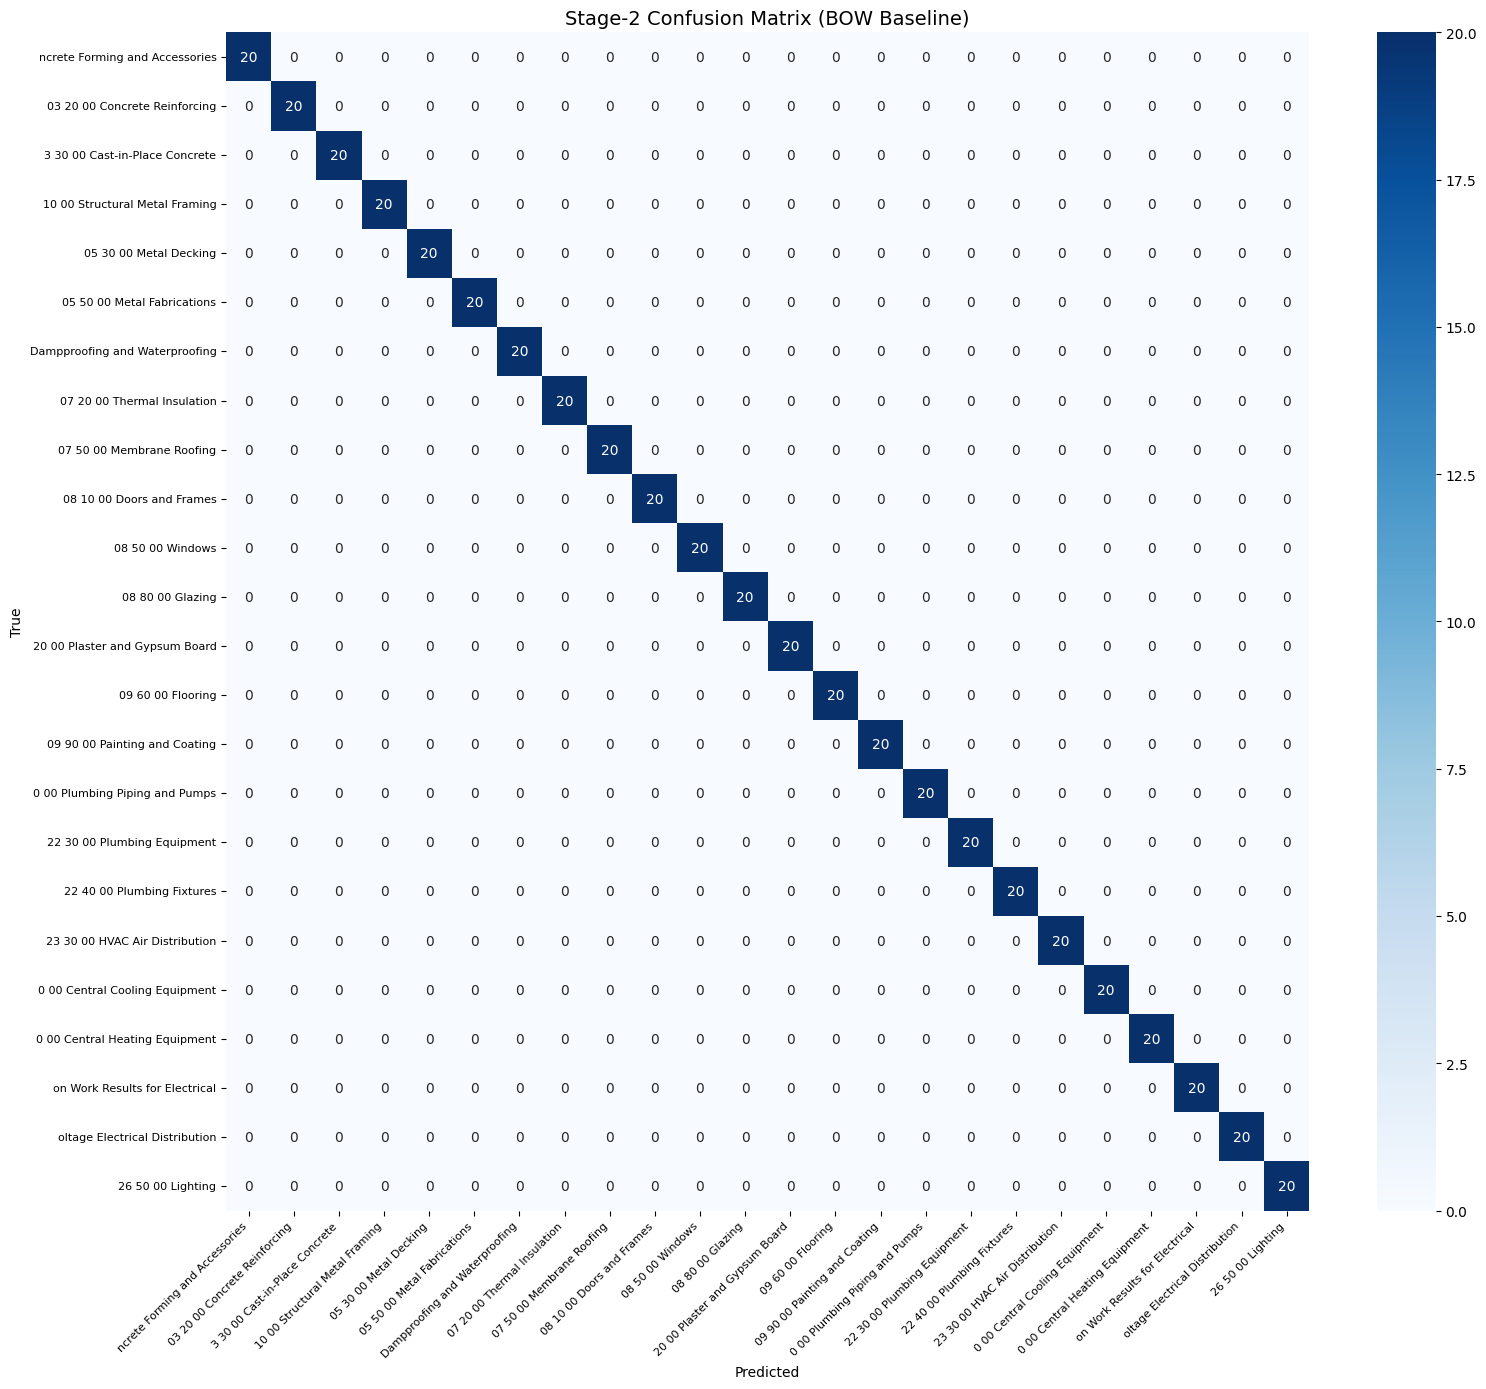

In [82]:
# Stage-2 Confusion Matrix (BOW)
import os
import random
import pandas as pd
import spacy
from spacy.training import Example
from sklearn.model_selection import train_test_split

if "y_true_stage2" not in globals() or "y_pred_stage2" not in globals():
    if "df" not in globals():
        df = pd.read_csv("./../data/text_format_training_data.csv")

    if "STAGE2_LABELS" not in globals():
        STAGE2_LABELS = sorted(df["stage2_label"].unique().tolist())

    if "train_df" not in globals() or "dev_df" not in globals():
        train_df, dev_df = train_test_split(
            df, test_size=0.2, random_state=42, stratify=df["stage2_label"]
        )

    if "nlp_stage2_bow" not in globals():
        stage2_model_path = "./../models/textformat_stage2_bow"
        if os.path.exists(stage2_model_path):
            nlp_stage2_bow = spacy.load(stage2_model_path)
        else:
            # Fallback: quickly train an in-memory Stage-2 BOW baseline
            nlp_stage2_bow = spacy.blank("en")
            textcat_stage2 = nlp_stage2_bow.add_pipe(
                "textcat",
                config={
                    "model": {
                        "@architectures": "spacy.TextCatBOW.v3",
                        "exclusive_classes": True,
                        "length": 262144,
                        "ngram_size": 2,
                        "no_output_layer": False,
                    },
                    "threshold": 0.5,
                },
            )
            for lbl in STAGE2_LABELS:
                textcat_stage2.add_label(lbl)

            train_examples_stage2 = []
            for _, row in train_df.iterrows():
                doc = nlp_stage2_bow.make_doc(row["full_item"])
                cats = {lbl: (lbl == row["stage2_label"]) for lbl in STAGE2_LABELS}
                train_examples_stage2.append(Example.from_dict(doc, {"cats": cats}))

            textcat_stage2.initialize(lambda: train_examples_stage2[:100])
            optimizer_stage2 = nlp_stage2_bow.create_optimizer()
            for _ in range(8):
                random.shuffle(train_examples_stage2)
                losses = {}
                for i in range(0, len(train_examples_stage2), 32):
                    batch = train_examples_stage2[i : i + 32]
                    nlp_stage2_bow.update(batch, sgd=optimizer_stage2, drop=0.3, losses=losses)

    if "dev_examples_stage2" not in globals():
        dev_examples_stage2 = []
        for _, row in dev_df.iterrows():
            doc = nlp_stage2_bow.make_doc(row["full_item"])
            cats = {lbl: (lbl == row["stage2_label"]) for lbl in STAGE2_LABELS}
            dev_examples_stage2.append(Example.from_dict(doc, {"cats": cats}))

    if "evaluate_model" not in globals():
        def evaluate_model(nlp_model, examples, label_list):
            y_true, y_pred = [], []
            for ex in examples:
                doc = nlp_model(ex.text)
                pred = max(doc.cats, key=doc.cats.get)
                true = max(ex.reference.cats, key=ex.reference.cats.get)
                y_pred.append(pred)
                y_true.append(true)
            return y_true, y_pred

    y_true_stage2, y_pred_stage2 = evaluate_model(
        nlp_stage2_bow, dev_examples_stage2, STAGE2_LABELS
    )

plot_confusion_matrix(
    y_true_stage2,
    y_pred_stage2,
    STAGE2_LABELS,
    "Stage-2 Confusion Matrix (BOW Baseline)",
    figsize=(16, 14),
)

## 12. Save Trained Models

In [83]:
from pathlib import Path

# Save BOW models
stage1_model_path = "./../models/textformat_stage1_bow"
stage2_model_path = "./../models/textformat_stage2_bow"

Path(stage1_model_path).mkdir(parents=True, exist_ok=True)
Path(stage2_model_path).mkdir(parents=True, exist_ok=True)

nlp_stage1_bow.to_disk(stage1_model_path)
nlp_stage2_bow.to_disk(stage2_model_path)

print(f"Stage-1 BOW model saved to: {stage1_model_path}")
print(f"Stage-2 BOW model saved to: {stage2_model_path}")

if HAS_TRF:
    trf_model_path = "./../models/textformat_stage1_trf"
    Path(trf_model_path).mkdir(parents=True, exist_ok=True)
    nlp_trf.to_disk(trf_model_path)
    print(f"Stage-1 Transformer model saved to: {trf_model_path}")

Stage-1 BOW model saved to: ./../models/textformat_stage1_bow
Stage-2 BOW model saved to: ./../models/textformat_stage2_bow
Stage-1 Transformer model saved to: ./../models/textformat_stage1_trf


## 13. Load & Predict — Production Usage

Demonstrates how to load saved models and classify new vendor documents.

In [84]:
# Reload from disk
loaded_stage1 = spacy.load("./../models/textformat_stage1_bow")
loaded_stage2 = spacy.load("./../models/textformat_stage2_bow")

new_doc = (
    "We propose to supply and install fiberglass batt insulation R-19 "
    "in all exterior wall cavities. Work includes vapor retarder installation "
    "on warm side. Product meets ASHRAE 90.1 energy code requirements. "
    "Insulation to be installed without gaps or compression per manufacturer guidelines."
)

result = predict_hierarchical(new_doc, loaded_stage1, loaded_stage2, STAGE1_TO_STAGE2)

print("NEW DOCUMENT CLASSIFICATION")
print("=" * 60)
print(f"Text:\n  {new_doc}\n")
print(f"Stage-1: {result['stage1_prediction']}")
print(f"  Confidence: {result['stage1_confidence']}")
print(f"\nStage-2: {result['stage2_prediction']}")
print(f"  Confidence: {result['stage2_confidence']}")
print(f"\nAll Stage-2 scores under predicted Stage-1:")
for lbl, score in result["all_stage2_scores"].items():
    print(f"  {lbl}: {score}")

NEW DOCUMENT CLASSIFICATION
Text:
  We propose to supply and install fiberglass batt insulation R-19 in all exterior wall cavities. Work includes vapor retarder installation on warm side. Product meets ASHRAE 90.1 energy code requirements. Insulation to be installed without gaps or compression per manufacturer guidelines.

Stage-1: Category 07 - Thermal and Moisture Protection
  Confidence: 0.9998

Stage-2: 07 20 00 Thermal Insulation
  Confidence: 0.9989

All Stage-2 scores under predicted Stage-1:
  07 20 00 Thermal Insulation: 0.9989
  07 10 00 Dampproofing and Waterproofing: 0.0002
  07 50 00 Membrane Roofing: 0.0001


In [85]:
# Batch prediction helper
def classify_documents(texts, nlp_stage1, nlp_stage2, stage1_to_stage2_map):
    """Classify a list of vendor documents and return a DataFrame."""
    results = []
    for text in texts:
        r = predict_hierarchical(text, nlp_stage1, nlp_stage2, stage1_to_stage2_map)
        results.append({
            "text": text[:80] + "..." if len(text) > 80 else text,
            "Stage-1": r["stage1_prediction"],
            "Stage-1 Conf": r["stage1_confidence"],
            "Stage-2": r["stage2_prediction"],
            "Stage-2 Conf": r["stage2_confidence"],
        })
    return pd.DataFrame(results)

if "test_documents" not in globals():
    test_documents = [
        "Supply and install 5000 PSI ready-mix concrete for elevated slabs per ACI 318.",
        "Install TPO membrane roofing over tapered insulation with flashing and edge metal.",
        "Furnish and install LED 2x4 recessed troffers with occupancy sensors.",
    ]

results_df = classify_documents(test_documents, loaded_stage1, loaded_stage2, STAGE1_TO_STAGE2)
print(results_df.to_string(index=False))

                                                                               text                                       Stage-1  Stage-1 Conf                         Stage-2  Stage-2 Conf
Supply and install 5000 PSI ready-mix concrete for elevated slabs per ACI 318. I...                        Category 03 - Concrete        0.9757 03 30 00 Cast-in-Place Concrete        0.8133
Proposal for installation of TPO 60-mil single-ply roofing membrane over tapered... Category 07 - Thermal and Moisture Protection        0.9860       07 50 00 Membrane Roofing        0.9630
Furnish and install LED 2x4 recessed troffer fixtures for office space per light...                      Category 26 - Electrical        0.7213               26 50 00 Lighting        0.3937


## Summary & Next Steps

### What was built
- Taxonomy: Stage-1 and Stage-2 categories
- Synthetic Data: vendor-style descriptions generated from domain templates
- BOW Baseline: fast Bag-of-Words classifiers for both stages
- Transformer Config: spaCy Transformers architecture using `roberta-base` via `en_core_web_trf`
- Hierarchical Pipeline: two-stage prediction (Stage-1 -> constrained Stage-2)

### Next Steps
1. Real Data: replace synthetic data with actual project text for fine-tuning
2. More Categories: extend taxonomy coverage as needed
3. Stage 3+: add deeper classification once Stage-1/Stage-2 accuracy is satisfactory
4. Active Learning: use low-confidence predictions to prioritize manual labeling
5. Augmentation: use paraphrasing models to augment training data
6. Deployment: export the spaCy pipeline as a REST API using FastAPI or similar

In [86]:
def predict_hierarchical(text, nlp_stage1, nlp_stage2, stage1_to_stage2_map):
    """Two-stage hierarchical prediction."""
    doc_stage1 = nlp_stage1(text)
    stage1_pred = max(doc_stage1.cats, key=doc_stage1.cats.get)
    stage1_conf = doc_stage1.cats[stage1_pred]

    doc_stage2 = nlp_stage2(text)
    valid_stage2 = stage1_to_stage2_map.get(stage1_pred, list(doc_stage2.cats.keys()))

    filtered_scores = {k: v for k, v in doc_stage2.cats.items() if k in valid_stage2}

    if filtered_scores:
        stage2_pred = max(filtered_scores, key=filtered_scores.get)
        stage2_conf = filtered_scores[stage2_pred]
    else:
        stage2_pred = max(doc_stage2.cats, key=doc_stage2.cats.get)
        stage2_conf = doc_stage2.cats[stage2_pred]

    return {
        "stage1_prediction": stage1_pred,
        "stage1_confidence": round(stage1_conf, 4),
        "stage2_prediction": stage2_pred,
        "stage2_confidence": round(stage2_conf, 4),
        "all_stage2_scores": {k: round(v, 4) for k, v in sorted(filtered_scores.items(), key=lambda x: -x[1])},
    }

In [87]:
# Demo: Predict on realistic vendor-style text using BOW models
test_documents = [
    "Supply and install 5000 PSI ready-mix concrete for elevated slabs per ACI 318. Includes placement, vibration, finishing and 7-day wet curing.",
    "Proposal for installation of TPO 60-mil single-ply roofing membrane over tapered insulation. Includes 20-year NDL warranty, all flashings and sheet metal edge details.",
    "Furnish and install LED 2x4 recessed troffer fixtures for office space per lighting schedule. Dimming drivers, occupancy sensors, and emergency battery packs included.",
]

print("=" * 90)
print("HIERARCHICAL CLASSIFICATION RESULTS (BOW Baseline)")
print("=" * 90)

for i, doc_text in enumerate(test_documents, 1):
    result = predict_hierarchical(doc_text, nlp_stage1_bow, nlp_stage2_bow, STAGE1_TO_STAGE2)
    print(f"\n--- Document {i} ---")
    print(f"Text:  {doc_text[:100]}...")
    print(f"Stage-1: {result['stage1_prediction']}  (conf: {result['stage1_confidence']})")
    print(f"Stage-2: {result['stage2_prediction']}  (conf: {result['stage2_confidence']})")

HIERARCHICAL CLASSIFICATION RESULTS (BOW Baseline)

--- Document 1 ---
Text:  Supply and install 5000 PSI ready-mix concrete for elevated slabs per ACI 318. Includes placement, v...
Stage-1: Category 03 - Concrete  (conf: 0.9757)
Stage-2: 03 30 00 Cast-in-Place Concrete  (conf: 0.8133)

--- Document 2 ---
Text:  Proposal for installation of TPO 60-mil single-ply roofing membrane over tapered insulation. Include...
Stage-1: Category 07 - Thermal and Moisture Protection  (conf: 0.986)
Stage-2: 07 50 00 Membrane Roofing  (conf: 0.963)

--- Document 3 ---
Text:  Furnish and install LED 2x4 recessed troffer fixtures for office space per lighting schedule. Dimmin...
Stage-1: Category 26 - Electrical  (conf: 0.7213)
Stage-2: 26 50 00 Lighting  (conf: 0.3937)


## 11. Full Evaluation — Confusion Matrices

In [88]:
def plot_confusion_matrix(y_true, y_pred, labels, title, figsize=(10, 8)):
    """Plot a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    short_labels = [lbl.split(" - ")[-1] if " - " in lbl else lbl[-30:] for lbl in labels]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=short_labels, yticklabels=short_labels, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

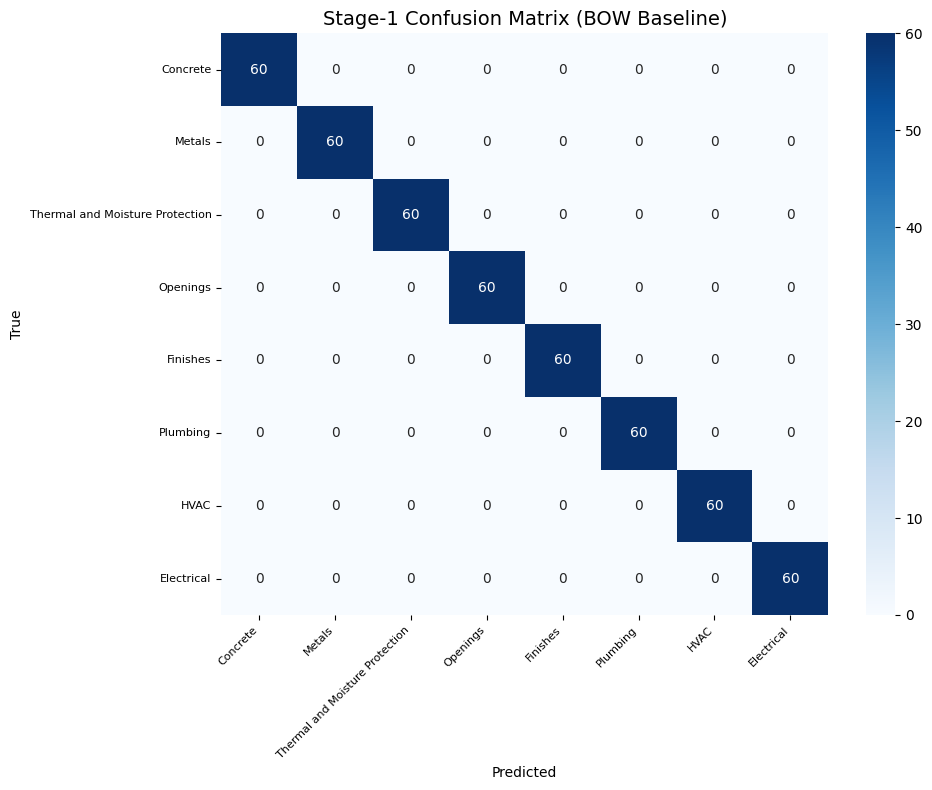

In [89]:
# Stage-1 Confusion Matrix (BOW)
plot_confusion_matrix(y_true_stage1, y_pred_stage1, STAGE1_LABELS,
                      "Stage-1 Confusion Matrix (BOW Baseline)", figsize=(10, 8))

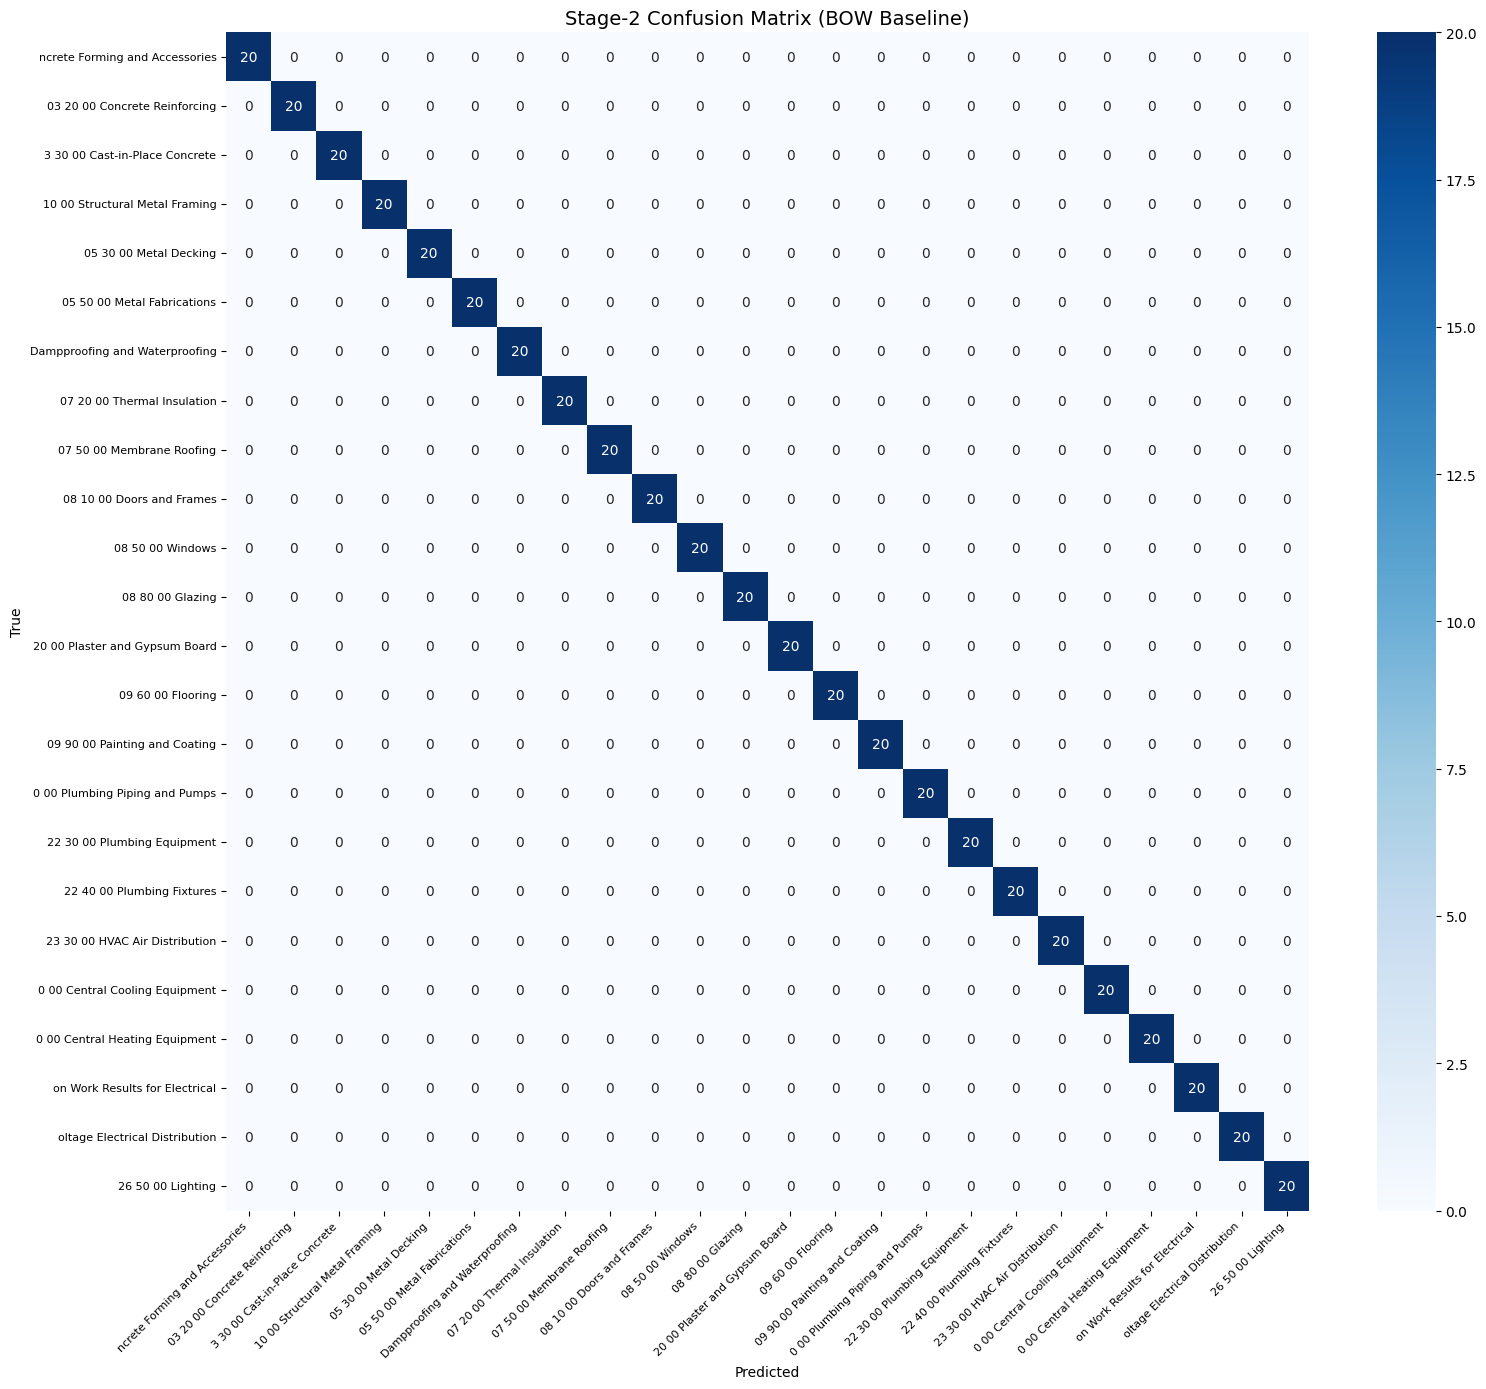

In [90]:
# Stage-2 Confusion Matrix (BOW)
plot_confusion_matrix(y_true_stage2, y_pred_stage2, STAGE2_LABELS,
                      "Stage-2 Confusion Matrix (BOW Baseline)", figsize=(16, 14))

## 12. Save Trained Models

In [91]:
from pathlib import Path

# Save BOW models
stage1_model_path = "./../models/textformat_stage1_bow"
stage2_model_path = "./../models/textformat_stage2_bow"

Path(stage1_model_path).mkdir(parents=True, exist_ok=True)
Path(stage2_model_path).mkdir(parents=True, exist_ok=True)

nlp_stage1_bow.to_disk(stage1_model_path)
nlp_stage2_bow.to_disk(stage2_model_path)

print(f"Stage-1 BOW model saved to: {stage1_model_path}")
print(f"Stage-2 BOW model saved to: {stage2_model_path}")

if HAS_TRF:
    trf_model_path = "./../models/textformat_stage1_trf"
    Path(trf_model_path).mkdir(parents=True, exist_ok=True)
    nlp_trf.to_disk(trf_model_path)
    print(f"Stage-1 Transformer model saved to: {trf_model_path}")

Stage-1 BOW model saved to: ./../models/textformat_stage1_bow
Stage-2 BOW model saved to: ./../models/textformat_stage2_bow
Stage-1 Transformer model saved to: ./../models/textformat_stage1_trf


## 13. Load & Predict — Production Usage

Demonstrates how to load saved models and classify new vendor documents.

In [92]:
# Reload from disk
loaded_stage1 = spacy.load("./../models/textformat_stage1_bow")
loaded_stage2 = spacy.load("./../models/textformat_stage2_bow")

new_doc = (
    "We propose to supply and install fiberglass batt insulation R-19 "
    "in all exterior wall cavities. Work includes vapor retarder installation "
    "on warm side. Product meets ASHRAE 90.1 energy code requirements. "
    "Insulation to be installed without gaps or compression per manufacturer guidelines."
)

result = predict_hierarchical(new_doc, loaded_stage1, loaded_stage2, STAGE1_TO_STAGE2)

print("NEW DOCUMENT CLASSIFICATION")
print("=" * 60)
print(f"Text:\n  {new_doc}\n")
print(f"Stage-1: {result['stage1_prediction']}")
print(f"  Confidence: {result['stage1_confidence']}")
print(f"\nStage-2: {result['stage2_prediction']}")
print(f"  Confidence: {result['stage2_confidence']}")
print(f"\nAll Stage-2 scores under predicted Stage-1:")
for lbl, score in result["all_stage2_scores"].items():
    print(f"  {lbl}: {score}")

NEW DOCUMENT CLASSIFICATION
Text:
  We propose to supply and install fiberglass batt insulation R-19 in all exterior wall cavities. Work includes vapor retarder installation on warm side. Product meets ASHRAE 90.1 energy code requirements. Insulation to be installed without gaps or compression per manufacturer guidelines.

Stage-1: Category 07 - Thermal and Moisture Protection
  Confidence: 0.9998

Stage-2: 07 20 00 Thermal Insulation
  Confidence: 0.9989

All Stage-2 scores under predicted Stage-1:
  07 20 00 Thermal Insulation: 0.9989
  07 10 00 Dampproofing and Waterproofing: 0.0002
  07 50 00 Membrane Roofing: 0.0001


In [93]:
# Batch prediction helper
def classify_documents(texts, nlp_stage1, nlp_stage2, stage1_to_stage2_map):
    """Classify a list of vendor documents and return a DataFrame."""
    results = []
    for text in texts:
        r = predict_hierarchical(text, nlp_stage1, nlp_stage2, stage1_to_stage2_map)
        results.append({
            "text": text[:80] + "..." if len(text) > 80 else text,
            "Stage-1": r["stage1_prediction"],
            "Stage-1 Conf": r["stage1_confidence"],
            "Stage-2": r["stage2_prediction"],
            "Stage-2 Conf": r["stage2_confidence"],
        })
    return pd.DataFrame(results)

results_df = classify_documents(test_documents, loaded_stage1, loaded_stage2, STAGE1_TO_STAGE2)
print(results_df.to_string(index=False))

                                                                               text                                       Stage-1  Stage-1 Conf                         Stage-2  Stage-2 Conf
Supply and install 5000 PSI ready-mix concrete for elevated slabs per ACI 318. I...                        Category 03 - Concrete        0.9757 03 30 00 Cast-in-Place Concrete        0.8133
Proposal for installation of TPO 60-mil single-ply roofing membrane over tapered... Category 07 - Thermal and Moisture Protection        0.9860       07 50 00 Membrane Roofing        0.9630
Furnish and install LED 2x4 recessed troffer fixtures for office space per light...                      Category 26 - Electrical        0.7213               26 50 00 Lighting        0.3937


## Summary & Next Steps

### What was built
- Taxonomy: Stage-1 and Stage-2 categories
- Synthetic Data: vendor-style descriptions generated from domain templates
- BOW Baseline: fast Bag-of-Words classifiers for both stages
- Transformer Config: spaCy Transformers architecture using `roberta-base` via `en_core_web_trf`
- Hierarchical Pipeline: two-stage prediction (Stage-1 -> constrained Stage-2)

### Next Steps
1. Real Data: replace synthetic data with actual project text for fine-tuning
2. More Categories: extend taxonomy coverage as needed
3. Stage 3+: add deeper classification once Stage-1/Stage-2 accuracy is satisfactory
4. Active Learning: use low-confidence predictions to prioritize manual labeling
5. Augmentation: use paraphrasing models to augment training data
6. Deployment: export the spaCy pipeline as a REST API using FastAPI or similar